In [10]:
### THIS IS NOW WORKING ... to the best of my knowledge

import numpy as np
import matplotlib.pyplot as plt
import json
import sys
import math
sys.path.append("..")
sys.path.append("../models")
from models.data_handler import data_wrangler
import models.modelbase.mltools as mlt
from modelbase.cascade_late_a import model_cascade2_late_a
from modelbase.cascade_mid import model_cascade2_mid
from modelbase.cascade_early import model_cascade2_early
from modelbase.cascade_early_b import model_cascade2_early_b
from modelbase.vit_pyrencoder import multi_vit
from modelbase.cube_cnn import model_flat2

from osgeo import gdal

In [26]:
### set up data and file info that we need to run everything

loc_prefix = "../models/trained/"
data_locs = ["../data/ml_sets/pyramid_v10/","../data/ml_sets/cube_v10/", "../data/ml_sets/adjust_v10/"]
raster_prefix = "../data/aligned_raster/colorado_ml_v10/"
raster_locs = ["ECOSTRESS_WUE_22_4326_0_0.tif", "ECOSTRESS_ESI_22_4326_0_0.tif", "GEDI_AGB_4326_0_0.tif"]
### model_tag: [model_dir, config_name, dataset, nice_name]
ops = {"c2_early_pyramid":  ["c2_early_b_pyramid",  "c2_early_b_pyramid",   "C2-Early (Pyramid)", model_cascade2_early(),     0],
       "c2_mid_pyramid":    ["c2_mid_pyramid",      "c2_mid_pyramid",       "C2-Mid (Pyramid)",   model_cascade2_mid(),       0],
       "c2_late_pyramid":   ["c2_late_a_pyramid",   "c2_late_a_pyramid",    "C2-Late (Pyramid)",  model_cascade2_late_a(),    0],
       "multivit_pyramid":  ["multi_vit_pyramid",   "multi_vit_pyramid",    "multi-ViT (Pyramid)",multi_vit(),                0],
       "c2_early_cube":     ["c2_early_b_cube",     "c2_early_b_cube",      "C2-Early (Cube)",    model_cascade2_early(),     1],
       "c2_mid_cube":       ["c2_mid_cube",         "c2_mid_cube",          "C2-Mid (Cube)",      model_cascade2_mid(),       1],
       "c2_late_cube":      ["c2_late_a_cube",      "c2_late_a_cube",       "C2-Late (Cube)",     model_cascade2_late_a(),    1],
       "multivit_cube":     ["multi_vit_cube",      "multi_vit_cube",       "multi-ViT (Cube)",   multi_vit(),                1],
       "c2_early_adj":      ["c2_early_b_adjust",   "c2_early_b_adjust"     "C2-Early (Adj)",     model_cascade2_early(),     2],
       "c2_mid_adj":        ["c2_mid_adjust",       "c2_mid_adjust",        "C2-Mid (Adj)",       model_cascade2_mid(),       2],
       "c2_late_adj":       ["c2_late_a_adjust",    "c2_late_a_adjust",     "C2-Late (Adj)",      model_cascade2_late_a(),    2],
       "multivit_adj":      ["multi_vit_adjust",    "multi_vit_adjust",     "multi-ViT (Adj)",    multi_vit(),                2], 
       "singletask_wue":    ["f2_singletask_0",     "c2_singletask_0",      "C2-Single (WUE)",    model_cascade2_late_a(),    1],
       "singletask_esi":    ["f2_singletask_1",     "c2_singletask_0",      "C2-Single (ESI)",    model_cascade2_late_a(),    1],
       "singletask_agb":    ["f2_singletask_2",     "c2_singletask_0",      "C2-Single (AGB)",    model_cascade2_late_a(),    1]}


In [27]:
### more of the previous

runon = ["c2_early_pyramid",
         "c2_mid_pyramid",
         "c2_late_a_pyramid",
         "multi_vit_pyramid",
         
         "c2_early_cube",
         "c2_mid_cube",
         "c2_late_a_cube",
         "multi_vit_cube",
         "f2_baseline_cube",
         
         "c2_early_adjust",
         "c2_mid_adjust",
         "c2_late_a_adjust",
         "multi_vit_adjust",
         "f2_baseline_adjust"]

runon = ["multivit_pyramid"]
runon = ["c2_late_pyramid"]

data_locs = ["../data/ml_sets/pyramid_v10/",
             "../data/ml_sets/cube_v10/",
             "../data/ml_sets/adjust_v10/"]
data_locs = ["../data/ml_sets/pyramid_nfanalysis/",
             "../data/ml_sets/cube_v10/",
             "../data/ml_sets/adjust_v10/"]

y_names = [["Water Use Efficiency", "wue"],
           ["Evaporative Stress Index", "esi"],
           ["Above Ground Biomass", "agb"]]

In [28]:
### load metadata
### don't load data yet -- too memory intensive to hang on to wranglers unfortunately
### load target raster layers

def dataload(datalocs, dli, dlfs_def=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]):

    print("loading data with dataload")
    metadata = mlt.load_metadata(datalocs[dli])
    metadata = metadata

    """if data_locs[dli] == "../data/ml_sets/pyramid_nfanalysis/":
        metadata["n_layers"] += 1
        metadata["x_layers"].append(14)
        metadata["y_layers"] = [15, 16, 17]
        mdltemp = metadata["layer_names"][15:]
        metadata["layer_names"].append()
        metadata[layer_names.append("")"""

    wrangler = data_wrangler(datalocs[dli], metadata["n_layers"], dlfs_def, 
                                   metadata["layer_dims"], 1000, metadata["buffer_nodata"], 
                                   metadata["x_layers"], metadata["y_layers"],  sample_weights=False,
                                   low_mem=False)
    wrangler.setup("val")
    temp_li = np.genfromtxt(datalocs[dli] + "/legal_ids.csv", delimiter=",").astype(int)
    #legalids = temp_li
    print(temp_li.shape)
    return metadata, wrangler, temp_li

working_crs = []

### need to get shapes, crs of original data...
y_geolayers = []
for i in range(3):
    raster_i = gdal.Open(raster_prefix+raster_locs[i])
    rasterband_i = raster_i.GetRasterBand(1)
    nodata_i = rasterband_i.GetNoDataValue()
    rastersize_i = (raster_i.RasterXSize, raster_i.RasterYSize)
    #tulh, tpxh, _, tulv, _, tpxv
    # tpxv -> abs (tpxv)
    geo_i = raster_i.GetGeoTransform()
    proj_i = raster_i.GetProjection()
    working_crs.append((geo_i[0], geo_i[3], geo_i[1], abs(geo_i[5])))
    print(working_crs[-1])
    print(geo_i)
    print(proj_i)
    print("^ *** ^")
    del rasterband_i
    del raster_i

    y_geolayers.append([nodata_i, rastersize_i, geo_i, proj_i])


(-109.05977631862096, 41.002830640734636, 0.0006298418999999995, 0.0006298418999999991)
(-109.05977631862096, 0.0006298418999999995, 0.0, 41.002830640734636, 0.0, -0.0006298418999999991)
GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
^ *** ^
(-109.05977631862096, 41.002830640734636, 0.0006298419, 0.0006298419)
(-109.05977631862096, 0.0006298419, 0.0, 41.002830640734636, 0.0, -0.0006298419)
GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
^ *** ^
(-109.06, 41.0, 0.008997741428571428, 0.

In [33]:
### overview -- 
### - function to read config files
### - functions to convert from crs -> index and index -> crs
### - iterate over models to run on
### -   iterate over folds to run on
### -       load wranglers and adjust to account for all data
### -       make predictions
### -       initialize open arrays to save computed geodata in
### -       un-extract data from cube indices to geo locations... should average along edges??
### -       save layers

runmodifier = "_nfanalysis1"

### initialize some necessary data fields...
fold_subset = [0]
guiding = 2
block_dims = [15, 15, 1]
block_res = [70, 70, 1000]

### function to open ML model config given loc..
def read_config(in_loc):
    config_in = open(in_loc)
    config_dict = json.load(config_in)
    return config_dict


### convert from coordinates to indices -- from create_pyramid_functions
def geo_idx(cx, cy, geopack): #ulh, ulv, psh, psv):
    ulh, ulv, psh, psv = geopack
    ix = (cx - ulh) / psh
    iy = (ulv - cy) / psv
    return ix, iy

### convert from indices to coordinates -- same...
def idx_geo(ix, iy, geopack): #ulh, ulv, psh, psv):
    ulh, ulv, psh, psv = geopack
    cx = ulh + (ix * psh)
    cy = ulv - (iy * psv)
    return cx, cy

### iterate over the models we want to run this on
for mk in runon:
    print("evaluating model", mk)
    ### verify config location
    print(loc_prefix + ops[mk][0] + "/" + ops[mk][1] + ".json")
    ### load config...
    model_config_i = read_config(loc_prefix + ops[mk][0] + "/" + ops[mk][1] + ".json")
    ### extract run params
    run_params = model_config_i["run_params"]
    ### extract model params
    model_parameters = model_config_i["model_params"]

    ### iterate over all folds we want to run on for this model:
    for fold in fold_subset:
        ### nead to load wrangler, metadata, etc. to begin with
        meta_mk, wrangler_mk, legal_mk = dataload(data_locs, ops[mk][-1], dlfs_def=[fold])
        ### ....
        print("fold", fold, end="...", flush=True)
        print("n legal ids:", len(legal_mk))
        ### set wrangler to appropriate fold...
        wrangler_mk.set_fold(fold)

        ### ^need to manually override index_len, self.val_ids[self.train_fold], lenn
        ### TODO -- this should really be functionality of the wrangler class, not this hacky process...
        megaids = np.arange(len(legal_mk))
        wrangler_mk.val_ids[wrangler_mk.train_fold] = megaids
        print("len comparison", len(wrangler_mk.val_ids[wrangler_mk.train_fold]), len(legal_mk))
        wrangler_mk.lenn = int(np.ceil(wrangler_mk.index_len / wrangler_mk.batch_size))
        wrangler_mk.index_len = len(megaids)

        ### done. now setup model from model id string
        working_model = ops[mk][3]
        working_name = run_params["model_name"] + "_" + str(fold)
        ### setup model... TODO should be a flag to reduce printed outputs here
        working_model.setup(model_parameters["hyperparams"], meta_mk, "../models/" + run_params["model_dir"], working_name,
                                    run_params["train_params"]["verbosity"], run_params["train_params"]["callbacks"])
        print("successful setup check")
        ### load model from file...
        working_model.load()
        print("loaded model", end="...", flush=True)
        ### make predictions, compute MSE over all points
        y_a, y_hat = working_model.predict(wrangler_mk)
        print("made predictions", end="...", flush=True)
        ### compute square error over all points
        ### this should come out as [3][n_pts...]
        y_mse = mlt.metric_mse(y_hat, y_a, "flattened", ["each"])
        ### make empty raster
        spatial_error = []
        spatial_predictions = []
        spatial_actual = []
        print("ys shape", y_hat[0].shape)

        ### convert shuffled ids to coords in raster space
        #val_to_int = wrangler_mk.val_ids[fold].copy()
        #val_to_int = val_to_int.astype(int)
        #coords_from_ids = legal_mk[val_to_int]

        ### set up spatial_error, spatial_predictions, and spatial_groundtruth
        for i in range(3):
            spatial_error.append(np.zeros((y_geolayers[i][1][0], y_geolayers[i][1][1])))
            spatial_error[-1] += y_geolayers[i][0]
            spatial_predictions.append(np.zeros((y_geolayers[i][1][0], y_geolayers[i][1][1])))
            spatial_predictions[-1] += y_geolayers[i][0]
            spatial_actual.append(np.zeros((y_geolayers[i][1][0], y_geolayers[i][1][1])))
            spatial_actual[-1] += y_geolayers[i][0]
            print(spatial_error[-1].shape)

        ### reduce memory load?
        del meta_mk
        
        print("len-fold", len(wrangler_mk.val_ids[fold]))
        ### iterate over all legal indices at this level, then over all y-layers (3), converting from id position (legal ids) to geo position of underlying layer:
        for j in range(len(legal_mk)):
            for i in range(3):
                ### coords in legal_samples wrt sampling grid 
                ### -- which is in the guiding crs. This is the AGB 1000m crs.
                ### -- need to...
                suli = legal_mk[j][0]
                sulj = legal_mk[j][1]
                if i < 2:
                    ### convert to general crs...
                    cx, cy = idx_geo(suli + 0.5, sulj + 0.5, working_crs[guiding])
                    ### convert back to this layer crs... 
                    li, lj = geo_idx(cx, cy, working_crs[i])
                    ### compute the ultimate UL index for this sample
                    ### round down to get central pixel UL
                    ### ... this is assuming odd dim sizes
                    ### subtract dim//2 to get ultimate UL
                    suli = int(li) - (block_dims[i] // 2)
                    sulj = int(lj) - (block_dims[i] // 2)
                
                ### save corresponding error, prediction, ground truth to geo array
                spatial_error[i][suli:suli+block_dims[i], sulj:sulj+block_dims[i]] = y_mse[0][i][j].reshape((block_dims[i], block_dims[i]))
                spatial_predictions[i][suli:suli+block_dims[i], sulj:sulj+block_dims[i]] = y_hat[i][j].reshape((block_dims[i], block_dims[i]))
                spatial_actual[i][suli:suli+block_dims[i], sulj:sulj+block_dims[i]] = y_a[i][j].reshape((block_dims[i], block_dims[i]))
        del wrangler_mk

        ### save everything
        outname_base = "../visualize/geographic/"
        outname_mods = [runmodifier + "_wue", runmodifier + "_esi", runmodifier + "_agb"]
        for i in range(3):
            ### save spatial error
            driver_i = gdal.GetDriverByName("GTiff")
            out_i = driver_i.Create(outname_base + ops[mk][0] + "_error_" + str(fold) + outname_mods[i] + ".tif",
                                  spatial_error[i].shape[0], spatial_error[i].shape[1], 1, gdal.GDT_Float32)
            out_i.SetGeoTransform(y_geolayers[i][2])
            out_i.SetProjection(y_geolayers[i][3])
            
            out_i.GetRasterBand(1).WriteArray(spatial_error[i].transpose())
            out_i.GetRasterBand(1).SetNoDataValue(y_geolayers[i][0])
            out_i.FlushCache()
            del out_i
            del driver_i

            ### save spatial predictions
            driver_i = gdal.GetDriverByName("GTiff")
            out_i = driver_i.Create(outname_base + ops[mk][0] + "_predictions_" + str(fold) + outname_mods[i] + ".tif",
                                  spatial_error[i].shape[0], spatial_error[i].shape[1], 1, gdal.GDT_Float32)
            out_i.SetGeoTransform(y_geolayers[i][2])
            out_i.SetProjection(y_geolayers[i][3])
            
            out_i.GetRasterBand(1).WriteArray(spatial_predictions[i].transpose())
            out_i.GetRasterBand(1).SetNoDataValue(y_geolayers[i][0])
            out_i.FlushCache()
            del out_i
            del driver_i

            ### save spatial underlying truth
            driver_i = gdal.GetDriverByName("GTiff")
            out_i = driver_i.Create(outname_base + ops[mk][0] + "_actual_" + str(fold) + outname_mods[i] + ".tif",
                                  spatial_error[i].shape[0], spatial_error[i].shape[1], 1, gdal.GDT_Float32)
            out_i.SetGeoTransform(y_geolayers[i][2])
            out_i.SetProjection(y_geolayers[i][3])
            
            out_i.GetRasterBand(1).WriteArray(spatial_actual[i].transpose())
            out_i.GetRasterBand(1).SetNoDataValue(y_geolayers[i][0])
            out_i.FlushCache()
            del out_i
            del driver_i
            print("converted", outname_mods[i], end="...", flush=True)
        print("complete")


### ALL GOOD

evaluating model c2_late_pyramid
../models/trained/c2_late_a_pyramid/c2_late_a_pyramid.json
loading data with dataload
metadata check
['34', 'x', '0', 'SRTM']
['34', 'x', '1', 'Aspect']
['34', 'x', '2', 'Slope']
['34', 'x', '3', 'EVC2022']
['34', 'x', '4', 'EVH2022']
['34', 'x', '5', 'EVT2022']
['34', 'x', '6', 'CC2022']
['34', 'x', '7', 'FVH2022']
['2', 'x', '8', 'Precip']
['2', 'x', '9', 'TempMIN']
['2', 'x', '10', 'TempMEAN']
['2', 'x', '11', 'TempMAX']
['2', 'x', '12', 'VaporMIN']
['2', 'x', '13', 'VaporMAX']
['1', 'x', '14', 'StandAge']
['15', 'y', '15', 'ECOSTRESSWUE']
['15', 'y', '16', 'ECOSTRESSESI']
['1', 'y', '17', 'GEDIAGB']
(21793, 2)
fold 0...n legal ids: 21793
len comparison 21793 21793
building cascade2_late_a model
[1, 2, 34]
[1, 6, 8]
convolutional dims... [1, 2, 2]
finished setting up


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_117     │ (None, 34, 34, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_118     │ (None, 34, 34, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_119     │ (None, 34, 34, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_120     │ (None, 34, 34, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_121     │ (None, 34, 34, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_122     │ (None, 34, 34, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_123     │ (None, 34, 34, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_124     │ (None, 34, 34, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_41      │ (None, 34, 34, 8) │          0 │ input_layer_117[… │
│ (Concatenate)       │                   │            │ input_layer_118[… │
│                     │                   │            │ input_layer_119[… │
│                     │                   │            │ input_layer_120[… │
│                     │                   │            │ input_layer_121[… │
│                     │                   │            │ input_layer_122[… │
│                     │                   │            │ input_layer_123[… │
│                     │                   │            │ input_layer_124[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_55 (Conv2D)  │ (None, 32, 32,    │      4,672 │ concatenate_41[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_55[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_125     │ (None, 2, 2, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_126     │ (None, 2, 2, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_127     │ (None, 2, 2, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_128     │ (None, 2, 2, 1)   │          0 │ -               

 Total params: 7,842,285 (29.92 MB)

 Trainable params: 7,842,045 (29.92 MB)

 Non-trainable params: 240 (960.00 B)

None
done setting up
successful setup check
loaded model...

/Users/jega7451/anaconda3/envs/firerx/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 90 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


shape sanity check 0 - (3000, 225) (3000, 225)
shape sanity check 1 - (3000, 225) (3000, 225)
shape sanity check 2 - (3000, 1) (3000, 1)
made predictions...mse dimensions check [(3000, 225)]
mse dimensions check [(3000, 225), (3000, 225)]
mse dimensions check [(3000, 225), (3000, 225), (3000, 1)]
ys shape (3000, 225)
(11142, 6367)
(11142, 6367)
(779, 445)
len-fold 21793


IndexError: index 3000 is out of bounds for axis 0 with size 3000

In [ ]:
### general idea here is to load national forest data and trim to shape of CO 


In [7]:
load_data = False
for modelkey in runon:
    ### move to next dataset if necessary
    if data_locs[ops[modelkey][4]] != load_data:
        load_data = data_locs[ops[modelkey][4]]

        with open(load_data + "info.txt", 'r') as infofile:
            metadata_total = infofile.read().replace('\n', ';')
        metadata_lines = metadata_total.split(";")
        metadata = []
        for metal in metadata_lines:
            if len(metal) > 0:
                metadata.append(metal.split(","))
        other_info = metadata.pop(0)
        other_info = {"n_folds": other_info[0], "buffer_nodata": other_info[1], "base_crs": other_info[2]}
        n_layers = len(metadata)
        layer_info = {"layer_dims": [], "x_layers": [], "y_layers": [], "layer_names": []}
        for j in range(n_layers):
            layer_info["layer_dims"].append(int(metadata[j][0]))
            layer_info["layer_names"].append(metadata[j][3])
            if metadata[j][1] == "x":
                layer_info["x_layers"].append(j)
            else:
                layer_info["y_layers"].append(j)
        ### load data handler
        wrangler = data_wrangler(load_data, 18, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], layer_info["layer_dims"],
                                    1000, other_info["buffer_nodata"], layer_info["x_layers"],
                                    layer_info["y_layers"], sample_weights=False, low_mem=False)

        wrangler.exclude_ids([14])
        layer_info["x_layers"] = wrangler.x_ids
        layer_info["layer_dims"] = [layer_info["layer_dims"][ii] for ii in layer_info["x_layers"] + layer_info["y_layers"]]
        layer_info["layer_names"] = [layer_info["layer_names"][ii] for ii in layer_info["x_layers"] + layer_info["y_layers"]]

        wrangler.set_fold(0)
        
    ### do with model
    print(ops[modelkey][0], ops[modelkey][2])
    config_in = open(ops[modelkey][0] + "/" + ops[modelkey][1] + ".json")
    mc = json.load(config_in)
    mc["model_params"]["hyperparams"] = mc["model_params"]["hyperparams"] | layer_info

    print(" - loaded config")

    if ops[modelkey][3] == "multi_vit":
        working_model = multi_vit()
    if ops[modelkey][3] == "f2_baseline":
        working_model = model_flat2()
    if ops[modelkey][3] == "c2_early":
        working_model = model_cascade2_early()
    if ops[modelkey][3] == "c2_mid":
        working_model = model_cascade2_mid()
    if ops[modelkey][3] == "c2_late_a":
        working_model = model_cascade2_late_a()
    working_model.setup(mc["model_params"]["hyperparams"], mc["model_params"]["model_dir"], mc["model_params"]["model_name"],
                        0, mc["run_params"]["train_params"]["callbacks"])
    working_model.modeldir = ops[modelkey][0]

    print(" - setup model")
    working_model.load()
    print(" - loaded weights")
    y_actual, y_predicted = working_model.predict(wrangler)
    print(" - made predictions")
    y_actual_through = y_actual
    ops[modelkey][5] = y_predicted

before exclusion [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
remaining after exclusion [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
c2_late_a_pyramid C2-Late (Pyramid)


FileNotFoundError: [Errno 2] No such file or directory: 'c2_late_a_pyramid/c2_late_a_pyramid.json'

In [16]:
### verify there are nonzero predictions...
for modelkey in runon:
    print(ops[modelkey][2], np.unique(ops[modelkey][5][1]))

c2_mid_cube [0.0000000e+00 3.4213066e-05 5.8531761e-05 ... 7.0418696e+00 7.1072702e+00
 7.3214793e+00]


In [17]:
### verify sane min, max values for y
for i in range(3):
    temp = y_actual_through[i].flatten()
    print(np.min(temp), np.max(temp))


0.0006718334625475109 0.9949031472206116
0.0034608598798513412 0.9989098906517029
0.12049760669469833 1.0453299283981323


In [18]:
from scipy import stats

In [19]:
### compute r2 values
r_values = []
slopes = []
intercepts = []
for modelkey in runon:
    r_values.append([])
    slopes.append([])
    intercepts.append([])
    for k in range(len(y_names)):
        slope, intercept, r_value, p_value, std_err = stats.linregress(y_actual_through[k].flatten(), ops[modelkey][5][k].flatten())
        r_values[-1].append(r_value)
        slopes[-1].append(slope)
        intercepts[-1].append(intercept)

/var/folders/9g/j1z88t6x1nnfc7myd3p_rzwh0000gp/T/ipykernel_10487/3315816774.py:14: RuntimeWarning: divide by zero encountered in log10
  tempk = np.log10(tempk)


5.262334787658619
2.8041394323353503
2.931457870689005
5.262334787658619


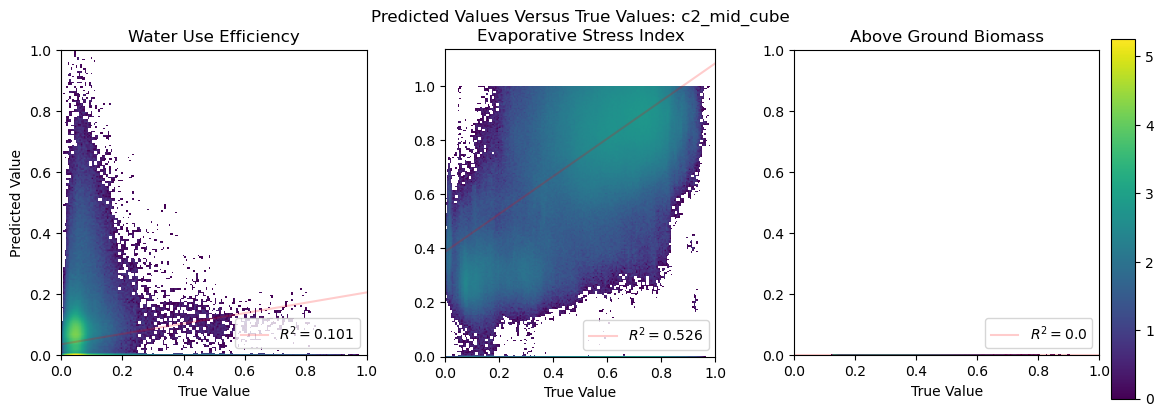

 - done with model


In [20]:
nbins = 200
idx = -1
for modelkey in runon:
    idx += 1
    fig, axes = plt.subplots(1, len(y_names), figsize=(12, 4))
    binned_y = []
    best_fits = []
    hist_y = []
    maxid = 0
    maxval = 0
    for k in range(len(y_names)):
        tempk = np.histogram2d(y_actual_through[k].flatten(), ops[modelkey][5][k].flatten(), bins=nbins, range=[[0, 1], [0, 1]])[0].transpose()
        #tempk[tempk == 1] = 2
        tempk = np.log10(tempk)
        hist_y.append(tempk)
        tempmax = np.max(tempk)
        print(tempmax) 
        if tempmax > maxval:
            maxid = k
            maxval = tempmax
    print(maxval)
    for k in range(len(y_names)):
        binned_y.append(axes[k].imshow(hist_y[k], vmin=0, vmax=maxval, origin='lower', extent=[0,1,0,1]))
        x_bf = np.linspace(0,1,100)
        y_bf = (x_bf * slopes[idx][k]) + (intercepts[idx][k]) 
        best_fits.append(axes[k].plot(x_bf, y_bf, label='$R^{2}=$' + str(round(r_values[idx][k], 3)), color="red", alpha=0.2))
        axes[k].legend(loc='lower right')
        #binned_y.append(axes[k].hist2d(y_actual_through[k].flatten(), predictions[i][j][k].flatten(), bins=200, norm="log", range=[[0, 1], [0, 1]]))
        axes[k].set(xlabel="True Value", title=y_names[k][0])
    
    axes[0].set(ylabel="Predicted Value")
    axes[1].set(title="Predicted Values Versus True Values: " + ops[modelkey][2] + "\n" + y_names[1][0])

    fig.subplots_adjust(right=0.99)
    cbar_ax = fig.add_axes([1, 0.005, 0.02, 0.9])
    fig.colorbar(binned_y[maxid], cax=cbar_ax)
    plt.savefig("predicted_actual_heatmaps/" + ops[modelkey][2] + "_log.png")
    plt.show()
    print(" - done with model")
